In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
processed_path = Path("../data/processed")

municipality_analysis = pd.read_csv(
    processed_path / "municipality_accessibility.csv"
)

da_accessibility = gpd.read_file(
    processed_path / "waterloo_accessibility.gpkg",
    layer="da_accessibility"
)

priority_underserved = gpd.read_file(
    processed_path / "waterloo_accessibility.gpkg",
    layer="priority_underserved"
)

In [3]:
print("Municipality table:", municipality_analysis.shape)
print("DA data:", da_accessibility.shape)
print("Priority DAs:", priority_underserved.shape)
print("CRS:", da_accessibility.crs)

Municipality table: (7, 7)
DA data: (766, 18)
Priority DAs: (52, 18)
CRS: EPSG:26917


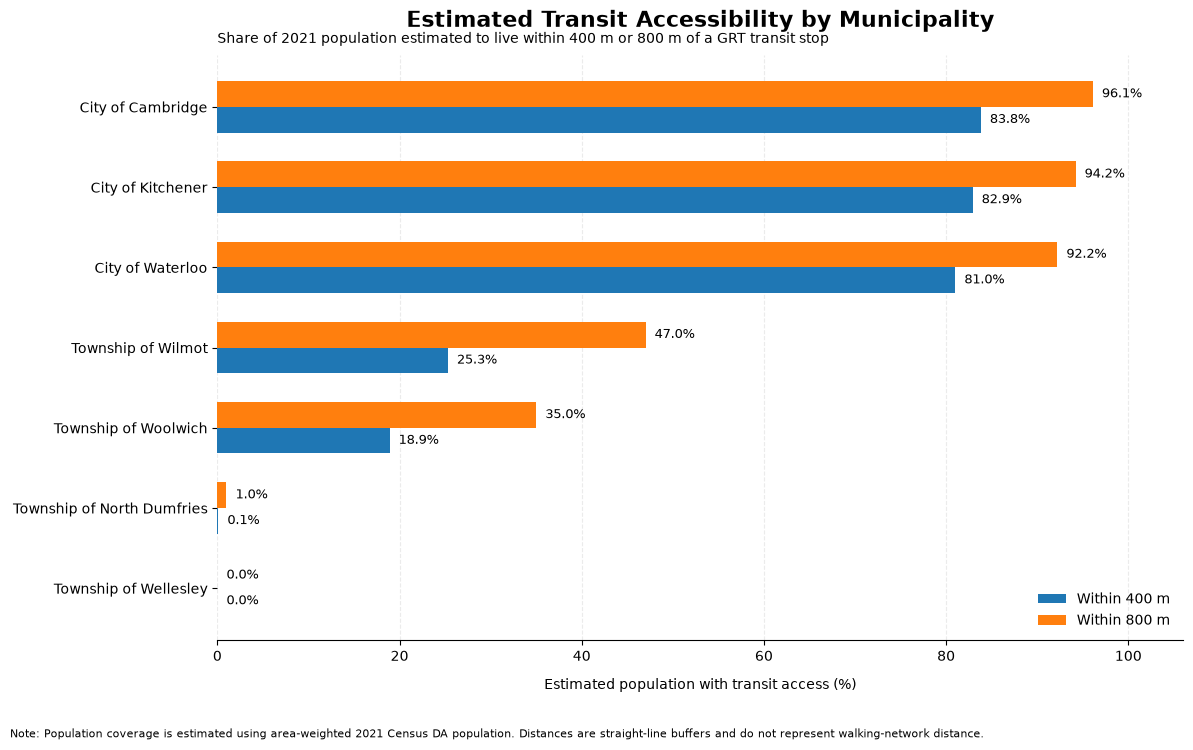

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# 1. Prepare data
# --------------------------------------------------

chart_data = municipality_analysis[
    [
        "FullName",
        "Pct_Access_400",
        "Pct_Access_800"
    ]
].copy()

# Highest 800 m accessibility at the top
chart_data = chart_data.sort_values(
    "Pct_Access_800",
    ascending=True
)

y = np.arange(len(chart_data))
bar_height = 0.32


# --------------------------------------------------
# 2. Create figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7.5))


# --------------------------------------------------
# 3. Draw bars
# --------------------------------------------------

bars_400 = ax.barh(
    y - bar_height / 2,
    chart_data["Pct_Access_400"],
    height=bar_height,
    label="Within 400 m"
)

bars_800 = ax.barh(
    y + bar_height / 2,
    chart_data["Pct_Access_800"],
    height=bar_height,
    label="Within 800 m"
)


# --------------------------------------------------
# 4. Municipality labels
# --------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    chart_data["FullName"],
    fontsize=10
)


# --------------------------------------------------
# 5. Percentage labels
# --------------------------------------------------

for bar in bars_400:

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )


for bar in bars_800:

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )


# --------------------------------------------------
# 6. Titles
# --------------------------------------------------

ax.set_title(
    "Estimated Transit Accessibility by Municipality",
    fontsize=16,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.02,
    "Share of 2021 population estimated to live within 400 m or 800 m of a GRT transit stop",
    transform=ax.transAxes,
    fontsize=10
)


# --------------------------------------------------
# 7. Axis formatting
# --------------------------------------------------

ax.set_xlabel(
    "Estimated population with transit access (%)",
    fontsize=10,
    labelpad=10
)

ax.set_xlim(0, 106)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


# --------------------------------------------------
# 8. Remove unnecessary borders
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# --------------------------------------------------
# 9. Legend
# --------------------------------------------------

ax.legend(
    frameon=False,
    loc="lower right"
)


# --------------------------------------------------
# 10. Methodology note
# --------------------------------------------------

fig.text(
    0.01,
    0.01,
    "Note: Population coverage is estimated using area-weighted 2021 Census DA population. "
    "Distances are straight-line buffers and do not represent walking-network distance.",
    fontsize=8
)


# --------------------------------------------------
# 11. Layout
# --------------------------------------------------

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)


# --------------------------------------------------
# 12. Save portfolio figure
# --------------------------------------------------

figures_path = Path("../figures")

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figures_path / "municipality_transit_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
boundary_path = Path(
    "../data/raw/boundaries/waterloo_municipal_boundaries.geojson"
)

municipalities = gpd.read_file(boundary_path)

municipalities_projected = municipalities.to_crs(
    da_accessibility.crs
)

print(municipalities_projected.crs)
print(municipalities_projected.shape)

EPSG:26917
(7, 4)


In [6]:
print("DA CRS:", da_accessibility.crs)
print("Priority CRS:", priority_underserved.crs)
print("Municipality CRS:", municipalities_projected.crs)

DA CRS: EPSG:26917
Priority CRS: EPSG:26917
Municipality CRS: EPSG:26917


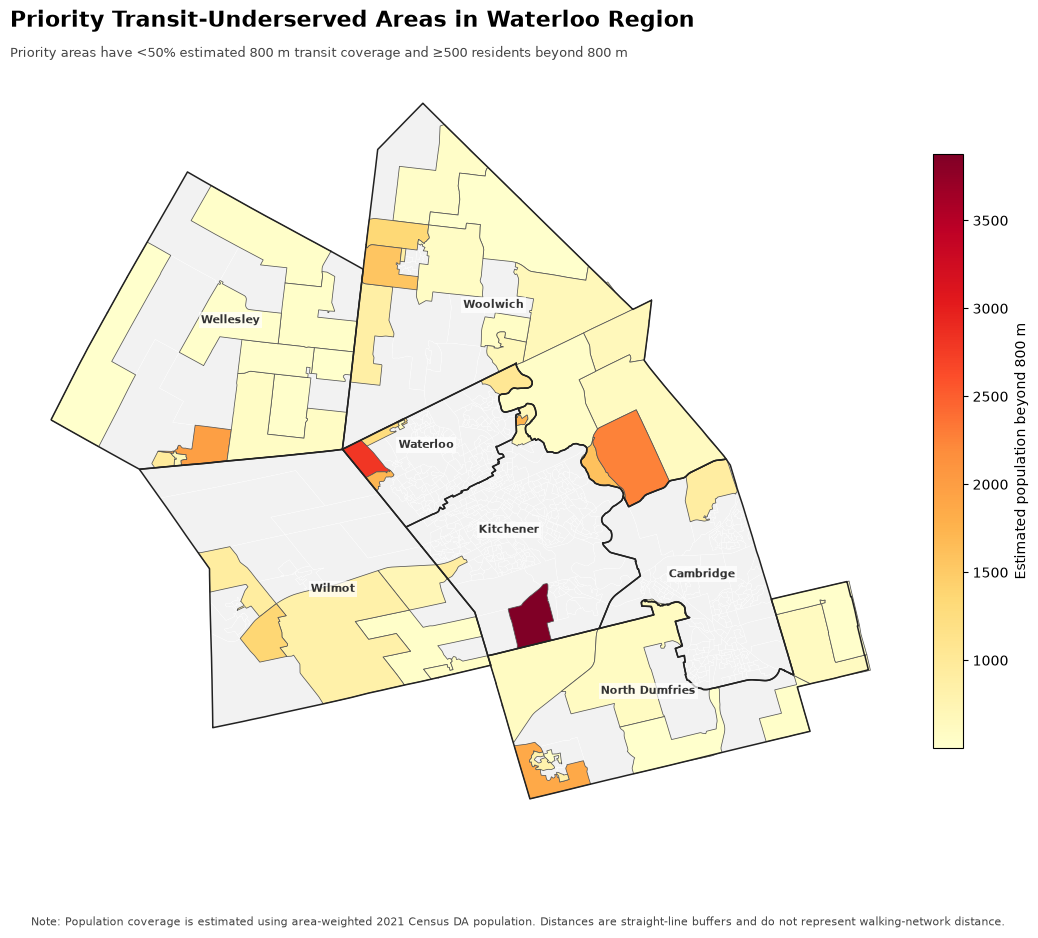

In [7]:
# --------------------------------------------------
# Figure 2: Portfolio-quality underserved area map
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 10))


# --------------------------------------------------
# 1. Background: all Census DAs
# --------------------------------------------------

da_accessibility.plot(
    ax=ax,
    facecolor="#f2f2f2",
    edgecolor="white",
    linewidth=0.25
)


# --------------------------------------------------
# 2. Priority underserved DAs
# --------------------------------------------------

priority_underserved.plot(
    ax=ax,
    column="Pop_Beyond_800",
    cmap="YlOrRd",
    edgecolor="#555555",
    linewidth=0.55,
    legend=True,
    legend_kwds={
        "label": "Estimated population beyond 800 m",
        "shrink": 0.70,
        "pad": 0.02
    }
)


# --------------------------------------------------
# 3. Municipality boundaries
# --------------------------------------------------

municipalities_projected.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.1
)


# --------------------------------------------------
# 4. Municipality labels
# --------------------------------------------------

municipality_labels = municipalities_projected.copy()

municipality_labels["geometry"] = (
    municipality_labels.geometry.representative_point()
)

for _, row in municipality_labels.iterrows():

    label = (
        row["FullName"]
        .replace("City of ", "")
        .replace("Township of ", "")
    )

    ax.annotate(
        text=label,
        xy=(row.geometry.x, row.geometry.y),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="#333333",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.70,
            pad=1.5
        )
    )


# --------------------------------------------------
# 5. Title
# --------------------------------------------------

ax.set_title(
    "Priority Transit-Underserved Areas in Waterloo Region",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=30
)


# --------------------------------------------------
# 6. Subtitle
# --------------------------------------------------

ax.text(
    0,
    1.015,
    "Priority areas have <50% estimated 800 m transit coverage and ≥500 residents beyond 800 m",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#444444"
)


# --------------------------------------------------
# 7. Remove axes
# --------------------------------------------------

ax.set_axis_off()


# --------------------------------------------------
# 8. Methodology note
# --------------------------------------------------

fig.text(
    0.08,
    0.035,
    "Note: Population coverage is estimated using area-weighted 2021 Census DA population. "
    "Distances are straight-line buffers and do not represent walking-network distance.",
    fontsize=8,
    color="#444444"
)


# --------------------------------------------------
# 9. Layout
# --------------------------------------------------

plt.tight_layout(
    rect=[0.05, 0.07, 0.98, 0.95]
)


# --------------------------------------------------
# 10. Save
# --------------------------------------------------

plt.savefig(
    figures_path / "priority_underserved_areas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# --------------------------------------------------
# Figure 3: Top 10 underserved DAs
# --------------------------------------------------

top10 = (
    da_accessibility
    .sort_values("Pop_Beyond_800", ascending=False)
    .head(10)
    .copy()
)

top10[
    [
        "DAUID",
        "FullName",
        "Population",
        "Pct_Access_800",
        "Pop_Beyond_800"
    ]
]

,DAUID,FullName,Population,Pct_Access_800,Pop_Beyond_800
756,35301060,City of Kitchener,5504.0,29.547777,3877.690374
751,35301033,City of Kitchener,9831.0,69.746753,2974.196730
743,35301043,City of Waterloo,3885.0,28.009390,2796.835179
750,35301048,Township of Woolwich,2551.0,11.387013,2260.517294
481,35300773,Township of Wellesley,1981.0,0.000000,1981.000000
22,35300804,Township of North Dumfries,1861.0,0.000000,1861.000000
739,35301039,City of Kitchener,1751.0,0.000000,1751.000000
746,35301044,City of Waterloo,3017.0,43.139304,1715.487184
749,35301047,Township of Woolwich,2585.0,37.879617,1605.811902
629,35300936,Township of Woolwich,1729.0,9.514056,1564.501978


In [9]:
top10["Municipality"] = (
    top10["FullName"]
    .str.replace("City of ", "", regex=False)
    .str.replace("Township of ", "", regex=False)
)

In [10]:
top10["Label"] = (
    top10["DAUID"].astype(str)
    + " — "
    + top10["Municipality"]
)

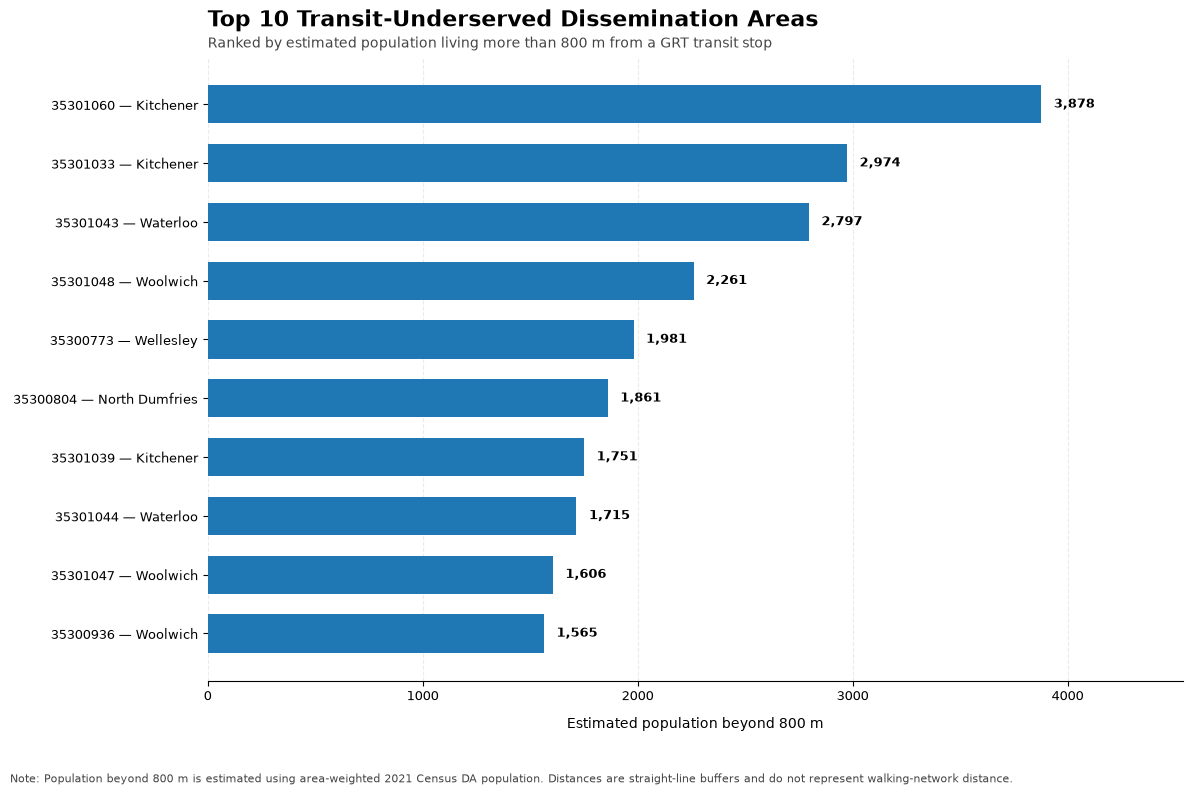

In [11]:
chart_top10 = top10.sort_values(
    "Pop_Beyond_800",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    chart_top10["Label"],
    chart_top10["Pop_Beyond_800"],
    height=0.65
)

# Title
ax.set_title(
    "Top 10 Transit-Underserved Dissemination Areas",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22
)

# Subtitle
ax.text(
    0,
    1.015,
    "Ranked by estimated population living more than 800 m from a GRT transit stop",
    transform=ax.transAxes,
    fontsize=10,
    color="#444444"
)

# Axis
ax.set_xlabel(
    "Estimated population beyond 800 m",
    fontsize=10,
    labelpad=10
)

ax.tick_params(
    axis="y",
    labelsize=9
)

ax.tick_params(
    axis="x",
    labelsize=9
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Leave room for value labels
max_value = chart_top10["Pop_Beyond_800"].max()

ax.set_xlim(
    0,
    max_value * 1.17
)

# Value labels
for bar in bars:

    value = bar.get_width()

    ax.text(
        value + max_value * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

# Methodology note
fig.text(
    0.01,
    0.015,
    "Note: Population beyond 800 m is estimated using area-weighted 2021 Census DA population. "
    "Distances are straight-line buffers and do not represent walking-network distance.",
    fontsize=8,
    color="#444444"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.savefig(
    figures_path / "top10_underserved_das.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()